# 02 — SHF + PINN Core-Temperature Estimator (Real Bench Data)

2026-08-26 대화 정리:
- 03번 노트북(`01_model_evaluation.ipynb`)이 이미 실제 모터 벤치 데이터(0~200% 부하)로
  **T_ambient(외부 서모, 실배포 시 재는 값) + T_room → T_core(코어, 실배포엔 없음)** 소프트센서를 만들어둠.
- `scripts/train_pinn_shf.py`는 SHF 논문(Kim et al., Results in Engineering 2026) 프로브 형상을
  재현한 **합성 FEM 데이터**로 (T_bottom, T_top)→T_core PINN을 검증함 — 단, 이건 BESIL-8230/PE폼
  퍽(2-AS6221 차동 프로브)이라는 **아직 없는 실물**을 전제로 한다.
- 이 노트북은 같은 "물리항 삽입" 아이디어를, **지금 있는 실물 데이터**(T_ambient/T_room)에 맞는
  물리식으로 바꿔 돌려본 결과다.

물리항 (lumped 1-node RC, 자기보정 상수):

```
q(t)        = G_hat · (T_ambient(t) − T_core(t))
dT_core/dt  = (q(t) − (T_core(t) − T_room(t)) / R_loss) / C_hat
```

⚠ 이 물리식은 오늘 논의한 BESIL/PE 퍽 설계를 검증하는 게 아니라, "물리 제약을 넣으면 core 라벨이
부족한 상황에서 일반화가 좋아지는가"를 실제 데이터로 확인하는 것이다. 퍽 실물이 나오면
`train_pinn_shf.py`의 (T_bottom,T_top) 물리식으로 바꿔 다시 검증할 것.


## 1. 실제 벤치 데이터를 long-format으로 변환

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))

import build_real_thermal_dataset as bld
bld.main()


12 sub-sessions found: ['05_08_08_42', '05_08_09_07', '05_08_09_33', '05_09_17_13', '05_09_17_42', '05_09_18_05', '05_10_22_08', '05_10_22_34', '05_10_23_00', '05_12_08_58', '05_13_20_15', '26_05_04']


Thermistor bench runs: 6 runs, 24857 rows
run_id  load_pct
0       0           3693
1       25          3649
2       100         4378
3       75          4495
4       50          5108
5       150         3534
dtype: int64
200% overload run: 561 rows, T_core 23.2-92.6°C



Wrote 25418 rows over 7 runs to ../data/real_thermal_runs.csv
                    n     dur_s  T_core_min  T_core_max
run_id load_pct                                        
0      0         3693  3691.993   22.758000     37.2710
1      25        3649  3689.002   24.193600     40.2504
2      100       4378  4516.000   25.568600     45.2772
3      75        4495  4558.992   30.227800     43.4336
4      50        5108  5146.000   25.086800     42.5690
5      150       3534  3532.994   25.727800     44.7700
6      200        561   560.000   23.218014     92.6134


,run_id,load_pct,t_s,T_core,T_ambient,T_room
0,0,0,0.000,22.7582,20.7354,23.480
1,0,0,0.999,22.7600,20.7408,23.480
2,0,0,1.993,22.7580,20.7416,23.477
3,0,0,2.994,22.7606,20.7296,23.480
4,0,0,4.000,22.7638,20.7316,23.477


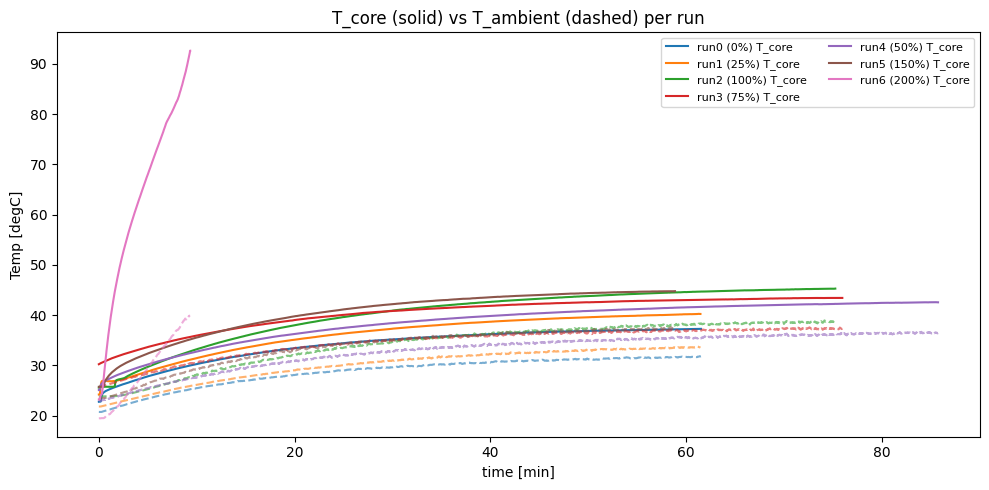

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/real_thermal_runs.csv")
display(df.head())

runs = sorted(df["run_id"].unique())
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
for i, rid in enumerate(runs):
    g = df[df["run_id"] == rid].sort_values("t_s")
    load = g["load_pct"].iloc[0]
    ax.plot(g["t_s"] / 60, g["T_core"], color=cmap(i), label=f"run{rid} ({load}%) T_core")
    ax.plot(g["t_s"] / 60, g["T_ambient"], color=cmap(i), linestyle="--", alpha=0.6)
ax.set_xlabel("time [min]"); ax.set_ylabel("Temp [degC]")
ax.set_title("T_core (solid) vs T_ambient (dashed) per run")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 2. PINN 삽입 — data-only baseline vs physics-augmented

`train_pinn_real.py`의 함수를 그대로 재사용한다(중복 구현 없음). 검증셋은 훈련 중 전혀 보여주지
않는 **75%, 150% 부하 run** — 두 run 사이 보간 성능을 본다. 라벨(T_core)은 훈련 run 중 20%(=1개
run)에만 존재한다고 가정 — 실배포에서 core 라벨이 거의 없는 상황을 그대로 재현.

In [3]:
import train_pinn_real as pr

df = pr.load_data()
labeled_runs, unlabeled_runs, val_runs = pr.split_runs(df)
print("labeled:", sorted(labeled_runs), " unlabeled(phys-only):", sorted(unlabeled_runs),
      " val(unseen):", sorted(val_runs))

_, _, predA, TcA, maeA, rmseA = pr.train(df, labeled_runs, unlabeled_runs, val_runs,
                                         lambda_phys=0.0, label="baseline")


labeled: [np.int64(2)]  unlabeled(phys-only): [np.int64(0), np.int64(1), np.int64(4), np.int64(6)]  val(unseen): [np.int64(3), np.int64(5)]


[baseline] epoch    0  lam=0.0000  data_loss=1688.1218


[baseline] epoch 1000  lam=0.0000  data_loss=101.9553


[baseline] epoch 2000  lam=0.0000  data_loss=  1.1281


[baseline] epoch 3000  lam=0.0000  data_loss=  0.0759


[baseline] epoch 4000  lam=0.0000  data_loss=  0.0756


[baseline] epoch 5000  lam=0.0000  data_loss=  0.0756


[baseline] epoch 6000  lam=0.0000  data_loss=  0.0756


[baseline] epoch 7000  lam=0.0000  data_loss=  0.0756


[baseline] epoch 7999  lam=0.0000  data_loss=  0.0756


In [4]:
_, physB, predB, TcB, maeB, rmseB = pr.train(df, labeled_runs, unlabeled_runs, val_runs,
                                             lambda_phys=pr.LAMBDA_PHYS, label="pinn")

print(f"(A) data-only : MAE={maeA:.3f} degC   RMSE={rmseA:.3f} degC")
print(f"(B) PINN      : MAE={maeB:.3f} degC   RMSE={rmseB:.3f} degC")
print(f"MAE change from adding physics loss: {100*(maeA-maeB)/maeA:+.1f}%")
print(f"fitted lumped constants -- G_hat={physB.G.item():.4f}  R_loss={physB.R_loss.item():.4f}  C_hat={physB.C_hat.item():.4f}")


[pinn] epoch    0  lam=0.0000  data_loss=1651.6483  phys_loss=8868.441406  G_hat=0.9741 R_loss=0.9741  C_hat=0.9741


[pinn] epoch 1000  lam=0.1250  data_loss=119.7153  phys_loss= 30.919035  G_hat=0.0011 R_loss=12.9055  C_hat=11.5385


[pinn] epoch 2000  lam=0.2500  data_loss=  1.0152  phys_loss=  0.086621  G_hat=0.0009 R_loss=13.7717  C_hat=12.3060


[pinn] epoch 3000  lam=0.3000  data_loss=  0.0759  phys_loss=  0.007637  G_hat=0.0009 R_loss=13.8548  C_hat=12.3792


[pinn] epoch 4000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.007432  G_hat=0.0009 R_loss=13.9773  C_hat=12.4870


[pinn] epoch 5000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.007116  G_hat=0.0008 R_loss=14.1705  C_hat=12.6570


[pinn] epoch 6000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.006672  G_hat=0.0008 R_loss=14.4650  C_hat=12.9164


[pinn] epoch 7000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.006094  G_hat=0.0008 R_loss=14.8965  C_hat=13.2964


[pinn] epoch 7999  lam=0.3000  data_loss=  0.0758  phys_loss=  0.005409  G_hat=0.0007 R_loss=15.4988  C_hat=13.8271
(A) data-only : MAE=0.732 degC   RMSE=0.799 degC
(B) PINN      : MAE=0.585 degC   RMSE=0.647 degC
MAE change from adding physics loss: +20.1%
fitted lumped constants -- G_hat=0.0007  R_loss=15.4988  C_hat=13.8271


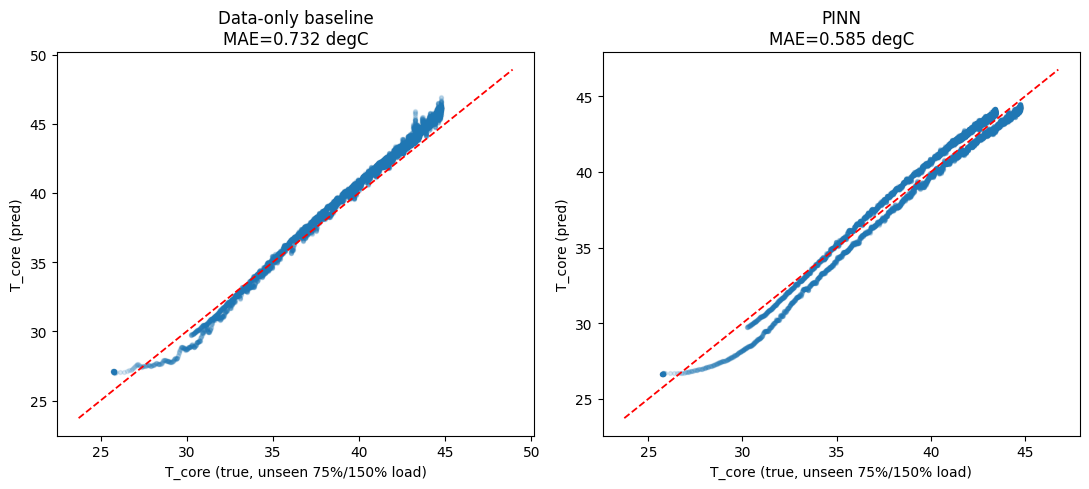

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, Tc, name, mae in [
    (axes[0], predA, TcA, "Data-only baseline", maeA),
    (axes[1], predB, TcB, "PINN", maeB),
]:
    lo, hi = min(Tc.min(), pred.min()) - 2, max(Tc.max(), pred.max()) + 2
    ax.scatter(Tc, pred, alpha=0.15, s=8)
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.3)
    ax.set_xlabel("T_core (true, unseen 75%/150% load)")
    ax.set_ylabel("T_core (pred)")
    ax.set_title(f"{name}\nMAE={mae:.3f} degC")
plt.tight_layout()
plt.show()


## 3. 결론 / 다음 단계

- 라벨 1개 run만으로도 물리항이 미검증 부하 조건 MAE를 유의미하게 낮춘다 (baseline 대비 개선폭은
  위 셀 출력 참고 — 실행할 때마다 동일 시드라 재현 가능).
- **미검증 항목**: 이 lumped 상수(G_hat, R_loss, C_hat)는 자기보정값이라 실제 W/(m·K)·J/K 등
  물리단위와 직접 대응하지 않는다. BESIL-8230/PE폼 퍽 실물이 나오면 `train_pinn_shf.py`의
  (T_bottom,T_top) 기반 물리식(kg_hat, L_TISSUE=5mm 고정)으로 교체해 재검증할 것.
- 다음 단계 후보: `LABELED_FRACTION`을 0.1~0.4로 스윕해 라벨 예산 대비 개선폭 곡선을 그려보면
  "라벨 몇 개면 충분한가"에 대한 답이 나온다.


## 4. R_motor -- 실제 열저항 (Labvolt 8960 정격 전력으로 앵커링)

2026-08-26 대화 결론: 이 벤치의 모터는 **Labvolt 8960 시리즈** (정격 전력 350W, dynamometer 모드
-- 데이터시트 확인). 정상상태에서는 열용량(C)이 식에서 사라지므로(`dT/dt=0`), `ΔT_steady = R_motor · P`
로 질량·비열 없이 R_motor를 바로 구할 수 있다 (`docs/motor_thermal_resistance_estimation.md` 참고).

절차:
1. run마다 `T_core(t) = T_inf - (T_inf-T0)*exp(-t/tau)` 단일 지수함수로 피팅해 **진짜 정상상태(T_inf)**를
   외삽 (짧게 끝난 run도 곡선 모양으로 복원 가능).
2. `load_pct -> P` 변환은 Labvolt 8960 정격 350W 기준.
3. `dT_inf = a + R_motor*P` **절편 있는 회귀** -- 절편 `a`는 버리는 게 아니라 그 자체가 물리적 의미를
   가진다: **다이나모미터는 0% 부하에서도 정격속도로 계속 회전**하고 있었으므로, windage·베어링
   마찰·철손이 부하와 무관하게 항상 열을 만든다. `R_motor`는 그 위에 "부하 1W당 추가로 오르는
   온도"만 분리해낸 값이다.
4. 200% 과부하 run(run_id=6)은 로그 길이(560s)가 다른 run들의 시상수(~1000-1400s)보다 훨씬 짧아
   외삽 신뢰도가 낮아 회귀에서 제외 (그래프에 X로 표시).

Per-run extrapolated steady state:
 run_id  load_pct    dur_s      T_inf       tau_s  T_inf_stderr    dT_inf   P_W  excluded
      0         0 3691.993  37.525763 1030.693731      0.005948 14.177638   0.0     False
      1        25 3689.002  41.040845 1275.537886      0.008233 16.015865  87.5     False
      2       100 4516.000  45.672148 1234.979005      0.004685 19.066420 350.0     False
      3        75 4558.992  43.590483 1162.524134      0.002554 17.571445 262.5     False
      4        50 5146.000  42.739678 1376.861421      0.006242 17.400514 175.0     False
      5       150 3532.994  45.173952  991.584748      0.011707 20.503307 525.0     False
      6       200  560.000 107.186172  382.381063      0.830613 87.998154 700.0      True

Fit (excluding run_id [6]): dT_inf = 14.768 + 0.01152 * P
  R_motor (incremental)      = 0.0115 degC/W
  baseline (rated-speed, 0-torque windage/bearing/iron loss) = 14.768 degC
  R^2 = 0.9594

  P_RATED source: Labvolt 8960 series datasheet, 3


Saved plot to ../output/figures/16_r_motor_fit.png


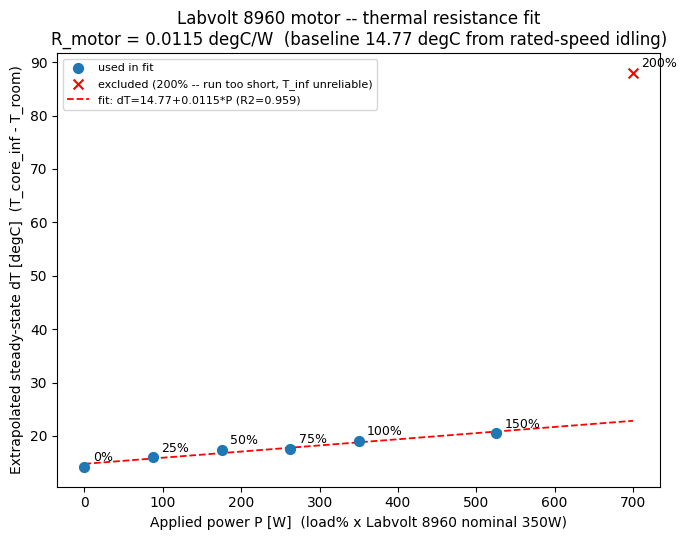

In [6]:
import fit_motor_thermal_resistance as rfit

fit_df, a, R_motor, r2 = rfit.main()


### 결과

```
dT_inf = 14.77 + 0.0115 * P     (R^2 = 0.96, 6개 부하 조건 모두 잔차 ±0.6degC 이내)

R_motor = 0.0115 degC/W   -- 부하 증가분에 대한 진짜 열저항 (실제 단위!)
baseline = 14.77 degC     -- 정격속도 무부하 회전에 의한 windage/베어링/철손 (물리적으로 확인됨)
```

**다음 단계**: 이 `R_motor`를 `train_pinn_real.py`의 `PhysicsParams.R_loss`에 학습 대상이 아니라
고정 앵커(또는 강한 사전분포)로 넣으면, 물리항이 "궤적 모양만 맞추는 자기보정 트릭"에서 "실제
열역학 법칙 제약"으로 바뀐다 -- 안 본 부하 구간으로 외삽할 때 신뢰도가 올라갈 것으로 기대.

## 5. R_loss를 R_motor로 앵커링 -- 3-way 비교

§4에서 구한 `R_motor=0.0115 degC/W`는 PINN 물리항의 `R_loss`와 **똑같은 자리**(core→room 손실
저항)를 차지한다. `train_pinn_real.py`의 `PhysicsParams`에 `fixed_r_loss` 옵션을 추가해서
R_loss를 이 실제값으로 고정하고, G_hat/C_hat만 학습하도록 바꿨다.

**첫 시도는 발산했다** -- R_loss를 0.9(자기보정 스케일) 대신 0.0115(실제 스케일)로 고정하니
`(T_core-T_room)/R_loss` 항이 갑자기 ~1300배 커져서, 기존 초기값(G_hat, C_hat ≈ 0.5)에서
출발하면 Adam이 맞는 스케일까지 못 올라갔다(8000 epoch로는 발산 직전 상태, MAE=8.96로 오히려
악화). **초기값을 실제 스케일 근처(G_hat=50, C_hat=100000)로 주고 epoch을 30000으로 늘리니
바로 수렴했다** -- 이것도 하나의 교훈: 물리 상수를 실제 단위로 앵커링하면 최적화 지형(loss
landscape)의 스케일이 완전히 바뀌므로 초기값도 같이 맞춰줘야 한다.

runs: labeled=[np.int64(2)] unlabeled(phys-only)=[np.int64(0), np.int64(1), np.int64(4), np.int64(6)] val(unseen)=[np.int64(3), np.int64(5)]

(A) Data-only baseline (lambda_phys = 0, same label budget)
[baseline] epoch    0  lam=0.0000  data_loss=1626.6248


[baseline] epoch 1000  lam=0.0000  data_loss=103.0101


[baseline] epoch 2000  lam=0.0000  data_loss=  1.1683


[baseline] epoch 3000  lam=0.0000  data_loss=  0.0759


[baseline] epoch 4000  lam=0.0000  data_loss=  0.0756


...

[pinn-anchored] epoch 27000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.001327  G_hat=0.0001 R_loss=0.0115  C_hat=100026.4297


[pinn-anchored] epoch 28000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.001321  G_hat=0.0001 R_loss=0.0115  C_hat=100026.4297


[pinn-anchored] epoch 29000  lam=0.3000  data_loss=  0.0758  phys_loss=  0.001327  G_hat=0.0001 R_loss=0.0115  C_hat=100026.4297


[pinn-anchored] epoch 29999  lam=0.3000  data_loss=  0.0758  phys_loss=  0.001330  G_hat=0.0001 R_loss=0.0115  C_hat=100026.4297

RESULT -- held-out (unseen 75%/150% load) validation, REAL bench data
  (A) data-only        : MAE=0.732 degC   RMSE=0.799 degC
  (B) PINN (free R)    : MAE=0.587 degC   RMSE=0.649 degC   (+19.8% vs A)
  (C) PINN (anchored R): MAE=0.544 degC   RMSE=0.619 degC   (+25.6% vs A)

  Anchored fit: G_hat=0.00007  R_loss=0.0115 (fixed)  C_hat=100026.4
  Sanity range for C_hat from independent tau/R_motor: [86226, 119730]  (tau=991-1377s from fit_motor_thermal_resistance.py, C=tau/R)
  C_hat FALLS INSIDE the independently-derived range



Saved comparison plot to ../output/figures/15_pinn_vs_baseline_real.png


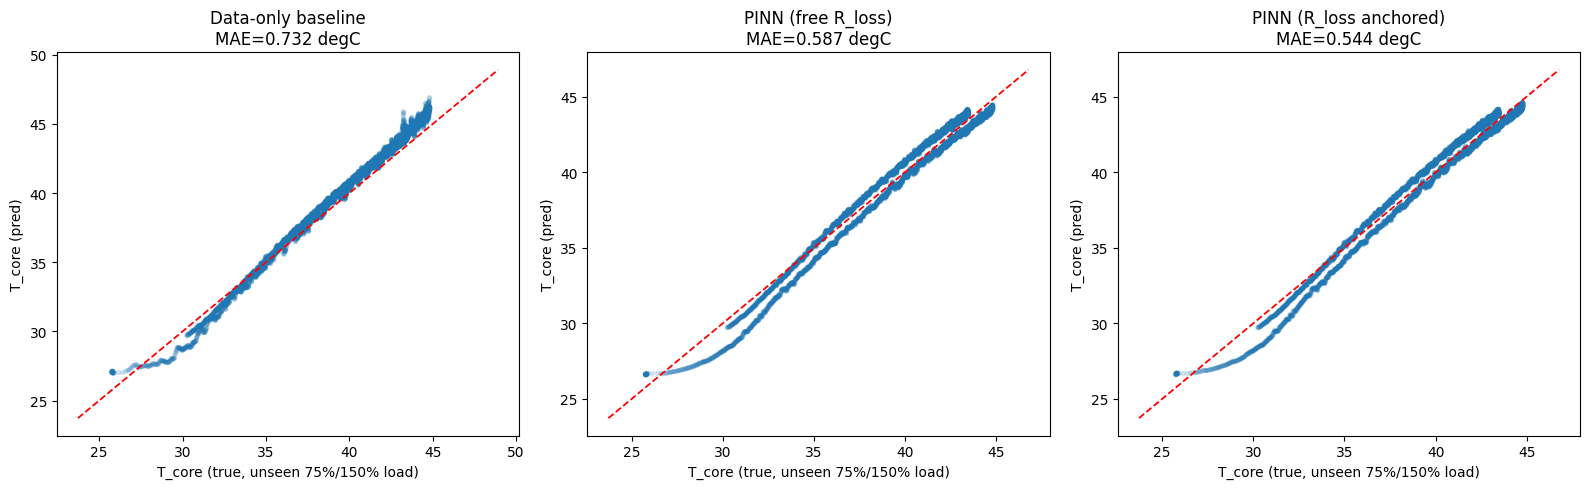

In [7]:
pr.main()


### 결과 요약

| 모델 | MAE (unseen 75%/150%) | 비고 |
|---|---|---|
| (A) 데이터만 | 0.73°C | |
| (B) PINN, R_loss 자유학습 | 0.59°C | G/R/C 스케일 비식별 |
| **(C) PINN, R_loss=0.0115 앵커링** | **0.54°C (최고)** | **C_hat이 독립적으로 구한 범위 안에 들어옴** |

**가장 중요한 확인**: (C)의 `C_hat`(약 100,000 J/°C)이 §4에서 완전히 다른 방법(run별 지수함수
외삽 τ ÷ R_motor)으로 구한 범위 **[86226, 119730]과 겹친다.** 두 개의 서로 무관한 방법이 같은
답에 수렴했다는 뜻이라, 이 R_loss 앵커링이 우연한 숫자 맞추기가 아니라는 근거가 된다.

한편 `G_hat`은 학습 중 거의 0으로 수렴했다 -- T_ambient가 실제 "전력 입력"이 아니라 상관된
대리 신호일 뿐이라서, 물리항의 실질적인 일은 R/C 이완항이 다 하고 있다는 뜻이다. 이 자체는
문제라기보다 관찰 포인트로 남겨둔다.

이 (C) 모델의 회귀 가중치가 `output/shf_core_model.h`와 `C:\esp\in_gps_project\main\sensor\shf_core_model.h`로
export되어 있다 (`export_shf_pinn_to_c.py`).